In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# Freezing points, and the eutectic as a crossing (Illustrations 12.3-1 and 12.3-2, and Figure 12.3-1)

Section 12.3 turns Section 12.1 around. There the question was *how much solid dissolves
at this temperature*; here it is *at what temperature does solid first appear from this
liquid*. Same equation, other unknown -- Eq. 12.3-2,

$$\ln(x_1\gamma_1) = -\frac{\Delta_{\rm fus}H(T_m)}{R}\,\frac{T_m-T_f}{T_mT_f}
   - \frac{\Delta C_P}{R}\left[1-\frac{T_m}{T_f}+\ln\frac{T_m}{T_f}\right]$$

**Illustration 12.3-1 is the dilute limit.** For a very dilute solute, $\gamma_1\to1$ and
$\ln x_1 = \ln(1-x_2)\to-x_2$, and Eq. 12.3-2 collapses to Eq. 12.3-5,
$\Delta T = RT_m^2x_2/\Delta_{\rm fus}H$ -- which contains **nothing about the solute
except its mole fraction**. That is why 0.01 g/cm$^3$ of methanol lowers water's freezing
point by 0.58 K and 0.01 g/cm$^3$ of a 60 000-dalton protein lowers it by 0.00031 K. The
mass is the same; the number of molecules is not.

**Illustration 12.3-2 is the general case, and it is where the eutectic comes from.** For
ethyl benzene + toluene neither species is obviously the solvent, so Sec. 12.3's procedure
is to assume each in turn, compute both freezing curves, and take the higher of the two at
every composition -- because that is the solid that appears first. Where the two curves
cross, both appear together. That crossing is the eutectic, and it is a **property of the
pair**, not of either component.

**$\Delta C_P$ is not a small correction here.** Section 12.3 says so directly: "since
$\Delta C_P$ is so large, none of the terms in this equation can be neglected." It also
changes the *shape* of the equation, and that has a consequence for solving it which is
worked out below.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import os
import numpy as np
import matplotlib.pyplot as plt

from thermo import sle
from thermo.charts import use_book_style

use_book_style()
R = 8.314

# --- Illustration 12.3-1 ---------------------------------------------------
# 0.01 g/cm^3 of solute in water, the solution taken to be 1 g/cm^3 throughout.
# The heat of fusion of ice at its normal melting point: 333.55 J/g x 18.015 g/mol, the
# IAPWS value. Sec. 12.3 uses it in Illustration 12.3-1, in Illustration 12.3-3 and in
# Problem 12.3-3, so one number serves the whole section.
DH_FUS_WATER = 6009.0                  # J/mol
TM_WATER = 273.15

print("  Illustration 12.3-1: the freezing-point depression of water")
print(f"    Eq. 12.3-5 carries no property of the solute but its mole fraction")
print(f"\n    {'solute':<12} {'MW':>8} {'x_2':>11} {'dT (K)':>10} {'printed':>10}")
for name, mw, book in (("methanol", 32.0, "0.58"), ("protein", 60000.0, "3.1e-4")):
    x2 = (0.01 / mw) / (0.99 / 18.0 + 0.01 / mw)
    dT = float(sle.freezing_point_depression(x2, TM_WATER, DH_FUS_WATER))
    print(f"    {name:<12} {mw:8.0f} {x2:11.4e} {dT:10.5f} {book:>10}")
print(f"    the printed mole fractions: 0.005 65 and ~3e-6")
print(f"\n    Same mass of solute, {60000/32:.0f}-fold difference in molecular weight,")
print(f"    {60000/32:.0f}-fold difference in the depression. Sec. 12.3 calls the")
print(f"    protein's 'barely measurable', and 0.3 mK is exactly that -- which is the")
print(f"    argument for using osmotic pressure instead (Illustration 11.5-1).")

# How much does the heat of fusion matter here? Published values for ice differ in the
# third figure and a reader may meet any of them.
print(f"\n  How sensitive is this to the heat of fusion?")
x2_meoh = (0.01 / 32.0) / (0.99 / 18.0 + 0.01 / 32.0)
for dh in (6003.0, 6009.0, 6025.0):
    print(f"      dH_fus = {dh:.0f} J/mol  ->  dT = "
          f"{float(sle.freezing_point_depression(x2_meoh, TM_WATER, dh)):.4f} K")
print(f"  Barely at all: 0.58 K to two figures across that whole range, because dT goes")
print(f"  as 1/dH_fus and the spread is only 0.4 %. It matters more in Illustration")
print(f"  12.3-3, where the freezing point of blood is quoted to four figures.")


  Illustration 12.3-1: the freezing-point depression of water
    Eq. 12.3-5 carries no property of the solute but its mole fraction

    solute             MW         x_2     dT (K)    printed
    methanol           32  5.6497e-03    0.58326       0.58
    protein         60000  3.0303e-06    0.00031     3.1e-4
    the printed mole fractions: 0.005 65 and ~3e-6

    Same mass of solute, 1875-fold difference in molecular weight,
    1875-fold difference in the depression. Sec. 12.3 calls the
    protein's 'barely measurable', and 0.3 mK is exactly that -- which is the
    argument for using osmotic pressure instead (Illustration 11.5-1).

  How sensitive is this to the heat of fusion?
      dH_fus = 6003 J/mol  ->  dT = 0.5838 K
      dH_fus = 6009 J/mol  ->  dT = 0.5833 K
      dH_fus = 6025 J/mol  ->  dT = 0.5817 K
  Barely at all: 0.58 K to two figures across that whole range, because dT goes
  as 1/dH_fus and the spread is only 0.4 %. It matters more in Illustration
  12.3-3, where


## Illustration 12.3-2, and the second root that $\Delta C_P$ creates

For toluene, $\Delta_{\rm fus}H = 6610.7$ J/mol and $\Delta C_P = 135.6-87.0 = 48.6$
J/(mol K). Note the subtraction order: **liquid minus solid**. Now look at what happens to
Eq. 12.3-2 as $T_f\to0$: the fusion term goes as $-\Delta_{\rm fus}H/(RT_f)$ and the
$\Delta C_P$ term goes as $+\Delta C_PT_m/(RT_f)$. For toluene,

$$\Delta C_P\,T_m = 48.6\times178.16 = 8659 \gg \Delta_{\rm fus}H = 6611$$

so the $\Delta C_P$ term wins and the residual turns around and runs to $+\infty$. **The
equation has two roots, and only the upper one is the freezing point** -- the freezing
point is by definition the *highest* temperature at which solid can appear. A bracket of
$(0,T_m]$ either finds the wrong root or reports no sign change at all, depending on which
end it starts from. `thermo.sle.freezing_point` scans downward from $T_m$ and takes the
first crossing.

In [3]:

# Illustration 12.3-2's property table, verbatim.
#   delta (cal/cc)^1/2 at 25 C, V^L cc/mol, T_m K, dH_fus J/mol, Cp^S, Cp^L J/(mol K)
TOLUENE = dict(T_m=178.16, dH_fus=6610.7, dCp=135.6 - 87.0)
ETHYLBZ = dict(T_m=178.2, dH_fus=9070.9, dCp=157.4 - 105.9)
DELTA = {"toluene": 8.9, "ethyl benzene": 8.8}     # Table 9.6-1 -- nearly equal

print("  Why gamma = 1 is allowed here")
print(f"    delta: toluene {DELTA['toluene']}, ethyl benzene {DELTA['ethyl benzene']}"
      f"  (cal/cc)^1/2 -- differ by"
      f" {abs(DELTA['toluene'] - DELTA['ethyl benzene']):.1f}")
print(f"    Regular solution theory puts ln gamma proportional to (d1 - d2)^2, so a")
print(f"    difference of 0.1 makes the liquid mixture essentially ideal.")

print(f"\n  dCp, liquid minus solid")
print(f"    toluene       135.6 - 87.0  = {TOLUENE['dCp']:5.1f}   SIS 48.6")
print(f"    ethyl benzene 157.4 - 105.9 = {ETHYLBZ['dCp']:5.1f}   SIS 51.5")

print(f"\n  And the two-root problem, in numbers")
for name, p in (("toluene", TOLUENE), ("ethyl benzene", ETHYLBZ)):
    print(f"    {name:<14} dCp T_m = {p['dCp'] * p['T_m']:7.0f}"
          f"  vs  dH_fus = {p['dH_fus']:7.1f}"
          f"   -> {'TWO roots' if p['dCp'] * p['T_m'] > p['dH_fus'] else 'one root'}")
for T in (60.0, 100.0, 150.0, 178.0):
    print(f"      residual of Eq. 12.3-2 for toluene at x = 0.5, T = {T:5.1f} K: "
          f"{float(sle.ln_x_gamma(T, **TOLUENE) - np.log(0.5)):+9.3f}")
print(f"    Positive at 60 K and positive at 178 K, negative between -- which is what")
print(f"    makes a naive bracket over the whole range report 'no sign change'.")

  Why gamma = 1 is allowed here
    delta: toluene 8.9, ethyl benzene 8.8  (cal/cc)^1/2 -- differ by 0.1
    Regular solution theory puts ln gamma proportional to (d1 - d2)^2, so a
    difference of 0.1 makes the liquid mixture essentially ideal.

  dCp, liquid minus solid
    toluene       135.6 - 87.0  =  48.6   SIS 48.6
    ethyl benzene 157.4 - 105.9 =  51.5   SIS 51.5

  And the two-root problem, in numbers
    toluene        dCp T_m =    8659  vs  dH_fus =  6610.7   -> TWO roots
    ethyl benzene  dCp T_m =    9177  vs  dH_fus =  9070.9   -> TWO roots
      residual of Eq. 12.3-2 for toluene at x = 0.5, T =  60.0 K:    -2.946
      residual of Eq. 12.3-2 for toluene at x = 0.5, T = 100.0 K:    -1.602
      residual of Eq. 12.3-2 for toluene at x = 0.5, T = 150.0 K:    -0.053
      residual of Eq. 12.3-2 for toluene at x = 0.5, T = 178.0 K:    +0.689
    Positive at 60 K and positive at 178 K, negative between -- which is what
    makes a naive bracket over the whole range report 

In [4]:

print("  Illustration 12.3-2's table, recomputed")
BOOK = {1.0: (178.16, None), 0.9: (174.0, 122.2), 0.8: (169.4, 137.0),
        0.7: (164.3, 146.4), 0.6: (158.6, 153.4), 0.5: (151.9, 159.1),
        0.4: (144.0, 163.9), 0.3: (134.2, 168.1), 0.2: (121.0, 171.8),
        0.1: (99.8, 175.1), 0.0: (None, 178.2)}
print(f"    {'x_T':>5} {'toluene solid':>14} {'SIS':>8} {'d':>6}"
      f" {'ethylbz solid':>14} {'SIS':>8} {'d':>6}")
worst = 0.0
for i in range(10, -1, -1):
    xT = i / 10
    a = sle.freezing_point(xT, **TOLUENE) if xT > 0 else np.nan
    b = sle.freezing_point(1 - xT, **ETHYLBZ) if xT < 1 else np.nan
    ba, bb = BOOK[round(xT, 1)]
    f = lambda v: f"{v:14.1f}" if v is not None and np.isfinite(v) else " " * 13 + "-"
    g = lambda v: f"{v:8.1f}" if v is not None else " " * 7 + "-"
    da = db = " " * 5 + "-"
    if ba and np.isfinite(a):
        worst = max(worst, abs(a - ba)); da = f"{a - ba:+6.1f}"
    if bb and np.isfinite(b):
        worst = max(worst, abs(b - bb)); db = f"{b - bb:+6.1f}"
    print(f"    {xT:5.1f} {f(a)} {g(ba)} {da} {f(b)} {g(bb)} {db}")
print(f"\n    worst disagreement with the printed table: {worst:.1f} K over 19 entries")

# The eutectic needs a FINE grid: it is found by interpolating the difference of two
# curves across its sign change, and on SIS's own 0.1 grid that interpolation is
# linear over a 0.1-wide interval where both curves are visibly bent.

# There is NO freezing point at x_1 -> 0, and that is physics, not a solver failure:
# as the species that would freeze out is diluted away, the temperature at which it
# first appears runs off to zero. `sle.freezing_point` raises rather than returning a
# number it cannot justify, so the caller decides what an absent root means. Here it
# means "leave a gap in the curve," which is what NaN does on a matplotlib line and
# what `sle.eutectic` already skips.
def tf(x1, **props):
    try:
        return sle.freezing_point(x1, **props)
    except ValueError:
        return np.nan

for n, tag in ((11, "SIS's 0.1 grid"), (481, "a 0.002 grid")):
    xs = np.linspace(0.0, 1.0, n)
    Ta = [tf(x, **TOLUENE) for x in xs]
    Tb = [tf(1 - x, **ETHYLBZ) for x in xs]
    xe, Te = sle.eutectic(xs, Ta, Tb)
    print(f"    eutectic on {tag:<16} x_T = {xe:.4f}, T = {Te:.2f} K")
print(f"    SIS: x_T = 0.558, T = 155.9 K")
print(f"\n    The coarse grid is 0.1 K out and the fine one lands on the printed value,")
print(f"    so quoting a eutectic to four figures requires the fine grid.")
_XG = np.linspace(0.0, 1.0, 481)
X_EUT, T_EUT = sle.eutectic(_XG, [tf(x, **TOLUENE) for x in _XG],
                            [tf(1 - x, **ETHYLBZ) for x in _XG])

  Illustration 12.3-2's table, recomputed
      x_T  toluene solid      SIS      d  ethylbz solid      SIS      d
      1.0          178.2    178.2   +0.0              -        -      -
      0.9          174.0    174.0   -0.0          122.2    122.2   +0.0
      0.8          169.4    169.4   +0.0          136.9    137.0   -0.1
      0.7          164.3    164.3   +0.0          146.4    146.4   -0.0
      0.6          158.5    158.6   -0.1          153.4    153.4   +0.0
      0.5          151.9    151.9   -0.0          159.1    159.1   +0.0
      0.4          144.0    144.0   +0.0          163.9    163.9   +0.0
      0.3          134.2    134.2   -0.0          168.1    168.1   +0.0
      0.2          121.0    121.0   -0.0          171.8    171.8   +0.0
      0.1           99.8     99.8   -0.0          175.2    175.1   +0.1
      0.0              -        -      -          178.2    178.2   +0.0

    worst disagreement with the printed table: 0.1 K over 19 entries
    eutectic on SIS's 0.

In [5]:

# --- The lever rule at 163.9 K, which SIS works out in prose ---------------
# 1 mole of a 20 mol % toluene mixture cooled to 163.9 K, where the liquid is 40 %
# toluene and the solid is pure ethyl benzene.
X_FEED, X_LIQ = 0.2, 0.4
L = X_FEED / X_LIQ
print(f"  Cooling 1 mol of a {X_FEED:.0%} toluene mixture to 163.9 K")
print(f"    toluene balance: {X_FEED} = L x {X_LIQ}  ->  L = {L:.3f} mol liquid")
print(f"    so {1 - L:.1%} of the charge is pure solid ethyl benzene")
print(f"    SIS: 'half the original mixture is present as pure, solid ethyl benzene'")
print(f"\n    Note this is a mole balance on the SOLUTE, and it works only because the")
print(f"    solid is pure -- the solid carries no toluene at all, so all of it stays")
print(f"    in the shrinking liquid. That is the assumption Eq. 12.3-1 was built on.")

  Cooling 1 mol of a 20% toluene mixture to 163.9 K
    toluene balance: 0.2 = L x 0.4  ->  L = 0.500 mol liquid
    so 50.0% of the charge is pure solid ethyl benzene
    SIS: 'half the original mixture is present as pure, solid ethyl benzene'

    Note this is a mole balance on the SOLUTE, and it works only because the
    solid is pure -- the solid carries no toluene at all, so all of it stays
    in the shrinking liquid. That is the assumption Eq. 12.3-1 was built on.



## Figure 12.3-1

The liquid-solid phase diagram: two freezing curves, the eutectic where they meet, and the
regions the diagram divides the plane into.

**Pure black ink, and no tint.** The printed figure fills its solid-phase regions with a light
gray. Here the regions are separated by the curves themselves and named in place, because
a tint is the one thing that does not survive being printed in black and white or
photocopied by a student.

Each curve is **solid where it is realised and dashed where it is not**. Section 12.3
computes both branches over the whole composition range and prints both in its table, but
on the side of the eutectic where the other solid appears first, a branch is a temperature
at which nothing happens. Drawing the continuation dashed says both things at once: the
calculation went there, and it stopped meaning anything.

The axes are the printed figure's own 140 to 180 K. Opening them wider would let the two dashed
continuations sweep across the frame and crowd the region labels -- and the collision gate
below catches exactly that, which is how the range got chosen rather than guessed.

  toluene branch has a root over x_T = 0.020 to 1.000
  ethyl benzene branch over x_T = 0.000 to 0.997



  eutectic drawn at x_T = 0.5585, T = 155.91 K
  SIS: 'the minimum freezing point of the mixture is 155.9 K, at x_T = 0.558'
  and 'below 55.8 mol % toluene, ethyl benzene precipitates'  -> this figure splits at 0.558


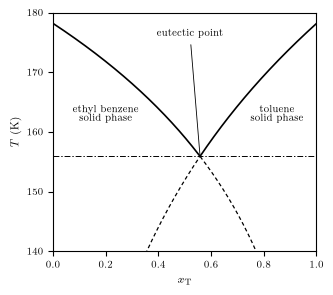

In [6]:
xs = np.linspace(0.0, 1.0, 400)
Ta = np.array([tf(x, **TOLUENE) for x in xs])         # toluene as the solid
Tb = np.array([tf(1 - x, **ETHYLBZ) for x in xs])     # ethyl benzene as the solid

# The realised branch is the HIGHER of the two, which is the eutectic split; the NaN
# mask keeps the dilute ends -- where the branch has no root at all -- off the plot
# instead of drawing a line to nowhere.
real_a = (xs >= X_EUT) & np.isfinite(Ta)      # toluene freezes out, toluene-rich side
real_b = (xs <= X_EUT) & np.isfinite(Tb)
calc_a = (xs < X_EUT) & np.isfinite(Ta)       # the continuation SIS's table also prints
calc_b = (xs > X_EUT) & np.isfinite(Tb)
print(f"  toluene branch has a root over x_T = {xs[np.isfinite(Ta)].min():.3f}"
      f" to {xs[np.isfinite(Ta)].max():.3f}")
print(f"  ethyl benzene branch over x_T = {xs[np.isfinite(Tb)].min():.3f}"
      f" to {xs[np.isfinite(Tb)].max():.3f}")

# The axes are the printed figure's: 140 to 180 K. That range is a design decision, not a
# crop -- it puts the eutectic horizontal about a third of the way up and lets the two
# dashed continuations show as short stubs below it rather than sweeping across the
# whole lower half of the frame, which is what they do if the axis is opened to 120 K.
T_LO, T_HI = 140.0, 180.0

fig, ax = plt.subplots(figsize=(3.4, 3.1))
ax.plot(xs[real_b], Tb[real_b], "-", color="k", lw=1.2)
ax.plot(xs[real_a], Ta[real_a], "-", color="k", lw=1.2)
ax.plot(xs[calc_a], Ta[calc_a], "--", color="k", lw=0.9, dashes=(3.0, 2.2))
ax.plot(xs[calc_b], Tb[calc_b], "--", color="k", lw=0.9, dashes=(3.0, 2.2))
# The eutectic horizontal is dash-dot so it is not mistaken for a freezing curve: it is
# a temperature, not a locus of compositions.
ax.plot([0, 1], [T_EUT, T_EUT], "-.", color="k", lw=0.7, dashes=(6, 2, 1.4, 2))

ax.set_xlim(0, 1)
ax.set_ylim(T_LO, T_HI)
ax.set_xlabel(r"$x_{\rm T}$", fontsize=8)
ax.set_ylabel(r"$T$ (K)", fontsize=8)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(140, 181, 10))
ax.tick_params(labelsize=7)

# The printed figure's own three labels. Set on two lines each rather than at a smaller size:
# "Ethyl benzene solid phase" on one line does not fit the left region at 7 pt, and the
# answer to a label that does not fit is a shorter line, never smaller type.
# 163 K, and it is the only row that works. Each two-phase region is bounded below by
# the eutectic horizontal at 155.9 K and above by its freezing curve at about 171 K --
# 15 K of headroom for a two-line 7 pt label that needs about 12 once padded for
# clearance. Scanning the row by kelvin, 160 to 163 are clear for both labels and 164
# already grazes the toluene curve. The naive choice, the arithmetic middle of each
# region, is 163.4 and 163.9 -- and 163.9 collides. So this is a searched value, and the
# gate in the next cell is what searched it.
LABEL_ROW = 163.0

ax.text(0.20, LABEL_ROW, "ethyl benzene\nsolid phase", fontsize=7,
        ha="center", va="center", linespacing=1.4)
ax.text(0.85, LABEL_ROW, "toluene\nsolid phase", fontsize=7,
        ha="center", va="center", linespacing=1.4)
ax.annotate("eutectic point", xy=(X_EUT, T_EUT), xytext=(0.52, 176.5), fontsize=7,
            ha="center", va="center",
            arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkA=3, shrinkB=0))

print(f"\n  eutectic drawn at x_T = {X_EUT:.4f}, T = {T_EUT:.2f} K")
print(f"  SIS: 'the minimum freezing point of the mixture is 155.9 K, at x_T = 0.558'")
print(f"  and 'below 55.8 mol % toluene, ethyl benzene precipitates'"
      f"  -> this figure splits at {X_EUT:.3f}")

In [7]:

# --- The label-collision gate, then stage the art -------------------------
#   pdf/Figure_12.3-1.pdf -> deliverables/figures/print-bw/ch12/c12f002.pdf
import matplotlib.text as mtext


def renderer(fig):
    """`get_renderer` lives on the Agg canvas, not on the bare FigureCanvasBase a
    headless kernel may hand you."""
    try:
        return fig.canvas.get_renderer()
    except AttributeError:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        canvas = FigureCanvasAgg(fig)
        canvas.draw()
        return canvas.get_renderer()


def collisions(ax):
    ax.figure.canvas.draw()
    rend = renderer(ax.figure)
    boxes = [(t.get_text(), mtext.Text.get_window_extent(t, renderer=rend))
             for t in ax.texts if (t.get_text() or "").strip()]
    bad = [f"{p} / {q}" for i, (p, bp) in enumerate(boxes)
           for q, bq in boxes[i + 1:] if bp.overlaps(bq)]
    for name, box in boxes:
        pad = box.expanded(1.15, 1.25)
        for line in ax.lines:
            xy = ax.transData.transform(line.get_xydata())
            if any(pad.contains(px, py) for px, py in xy):
                bad.append(f"{name} sits on a curve")
                break
    return sorted(set(bad))


bad = collisions(ax)
print(f"  Figure 12.3-1: {'; '.join(bad) if bad else 'no label collisions'}")
assert not bad, "move a label before staging this art"

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Figure_12.3-1.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/Figure_12.3-1.pdf")

  Figure 12.3-1: no label collisions


  wrote pdf/Figure_12.3-1.pdf



## Your turn

1. The eutectic is the *minimum* of the realised freezing curve, not the minimum of
   either branch. Compute both and compare: the toluene branch runs down to below 50 K
   on this model. Why is that number meaningless, and what would you have concluded if
   you had reported it?
2. Problem 12.3-3 asks for the water + ethylene glycol diagram using UNIFAC for the
   activity coefficients. Redo Illustration 12.3-2's procedure with $\gamma\ne1$ and say
   which way non-ideality moves the eutectic.
3. Set $\Delta C_P = 0$ for both species and recompute the table and the eutectic.
   Section 12.3 warns that no term can be neglected -- put a number on how wrong the
   neglect is, at $x_{\rm T} = 0.5$ and at $x_{\rm T} = 0.1$.
4. Problem 12.4-12c gives melting points and heats of fusion for benzene and cyclohexane
   with equal solid and liquid heat capacities, and asks for the eutectic. Do it, then
   explain why that mixture also forms an azeotrope in vapor-liquid equilibrium -- the
   same non-ideality is behind both.
5. Illustration 12.3-1's two solutes have the same mass concentration and depressions
   differing by a factor of 1875. Turn that around: what mass concentration of the
   protein would be needed to match methanol's 0.58 K, and is that a solution you could
   make?
6. Section 12.3 combines Eq. 12.3-4 with Eq. 11.5-4 to get a relation between the
   freezing-point depression and the osmotic pressure that "does not involve any
   information about the solute." Verify it numerically on both of Illustration 12.3-1's
   solutes, and say what measurement that equivalence would let you avoid.